In [1]:
# pixel test for input_neomod3.dat 
# to actually download that file (and because I accidently deleted it once...) 
# wget --no-check-certificate -O input_neomod3.dat https://www2.boulder.swri.edu/~davidn/NEOMOD_Simulator/input_neomod3.dat
# keeping rows only with iH = 45, ia = 17 ...


In [2]:
import re
import pandas as pd
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
import adam_core.coordinates
import pyarrow as pa
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, get_sun, GCRS

In [65]:
import re
import pandas as pd
from io import StringIO

input_file = "input_neomod3.dat"
output_file = "input_neomod3_TEST.dat"


with open(input_file) as fp:
    lines = fp.readlines()

header_idx = next(
    i for i, ln in enumerate(lines)
    if re.match(r"^\s*iH\s+ia\s+ie\s+ii\s+binned\s+mod\.\s+nu6\b", ln)
)


header_lines = lines[:header_idx+1]


raw_tokens = re.split(r"\s+", lines[header_idx].strip())
names = []
i = 0
while i < len(raw_tokens):
    if raw_tokens[i] == "binned" and i+1 < len(raw_tokens) and raw_tokens[i+1].startswith("mod."):
        names.append("binned mod.")
        i += 2
    else:
        names.append(raw_tokens[i])
        i += 1

data_lines = []
for ln in lines[header_idx+1:]:
    s = ln.strip()
    if not s or set(s) <= {"-", " "}:
        continue
    if re.match(r"^\d", s):
        data_lines.append(s)

df = pd.read_csv(StringIO("\n".join(data_lines)), sep=r"\s+", header=None, names=names)

# Filter rows 
df_small = df[(df["iH"] == 45) & (df["ia"] == 17)].copy()

print(f"Original model rows: {len(df)}")
print(f"Kept rows: {len(df_small)}")

# keeping header same
with open(output_file, "w") as fp:
    for ln in header_lines:
        fp.write(ln)

    for _, row in df_small.iterrows():
        fp.write(" ".join(str(x) for x in row.values) + "\n")

print(f"Wrote reduced NEOMOD model → {output_file}")


Original model rows: 566828
Kept rows: 293
Wrote reduced NEOMOD model → input_neomod3_TEST.dat


In [66]:


test_file = "input_neomod3_TEST.dat"


with open(test_file) as fp:
    lines = fp.readlines()

header_idx = next(
    i for i, ln in enumerate(lines)
    if re.match(r"^\s*iH\s+ia\s+ie\s+ii\s+binned\s+mod\.\s+nu6\b", ln)
)


raw_tokens = re.split(r"\s+", lines[header_idx].strip())
names = []
i = 0
while i < len(raw_tokens):
    if raw_tokens[i] == "binned" and i+1 < len(raw_tokens) and raw_tokens[i+1].startswith("mod."):
        names.append("binned mod.")
        i += 2
    else:
        names.append(raw_tokens[i])
        i += 1

data_lines = []
for ln in lines[header_idx+1:]:
    s = ln.strip()
    if not s or set(s) <= {"-", " "}:
        continue
    if re.match(r"^\d", s):
        data_lines.append(s)


df_test = pd.read_csv(StringIO("\n".join(data_lines)), sep=r"\s+", header=None, names=names)

df_test


,iH,ia,ie,ii,binned mod.,nu6,3:1,5:2,7:3,8:3,9:4,11:5,2:1,inner,Hun,Pho,JFC
0,45.0,17.0,5.0,1.0,1.362600,0.856,0.093,0.000,0.0,0.000,0.0,0.0,0.0,0.023,0.024,0.003,0.0
1,45.0,17.0,5.0,2.0,4.342200,0.874,0.069,0.005,0.0,0.000,0.0,0.0,0.0,0.020,0.029,0.002,0.0
2,45.0,17.0,5.0,3.0,7.884300,0.888,0.056,0.010,0.0,0.006,0.0,0.0,0.0,0.005,0.034,0.001,0.0
3,45.0,17.0,5.0,4.0,8.366000,0.873,0.072,0.001,0.0,0.003,0.0,0.0,0.0,0.002,0.042,0.007,0.0
4,45.0,17.0,5.0,5.0,7.147700,0.923,0.017,0.000,0.0,0.000,0.0,0.0,0.0,0.000,0.057,0.003,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,45.0,17.0,22.0,9.0,0.001516,0.472,0.423,0.000,0.0,0.000,0.0,0.0,0.0,0.079,0.013,0.013,0.0
289,45.0,17.0,22.0,10.0,0.000354,0.240,0.709,0.000,0.0,0.000,0.0,0.0,0.0,0.000,0.020,0.031,0.0
290,45.0,17.0,22.0,11.0,0.000568,0.713,0.196,0.000,0.0,0.000,0.0,0.0,0.0,0.000,0.028,0.062,0.0
291,45.0,17.0,22.0,12.0,0.000178,0.477,0.314,0.000,0.0,0.000,0.0,0.0,0.0,0.000,0.071,0.138,0.0


In [67]:
# to check its only iH = 45
print("unique iH:", df_test['iH'].unique())          # should be [45]


nz = np.argwhere(array4D > 0)
print("nonzero cells:", nz.shape[0])
print("first few nonzero indices (0-based):", nz[:5])

if nz.size:
    H_i, a_i, e_i, i_i = nz[0]
    print("1-based bins for first nz:", H_i+1, a_i+1, e_i+1, i_i+1)


unique iH: [45.]
nonzero cells: 17
first few nonzero indices (0-based): [[44 16  4  0]
 [44 16  4  1]
 [44 16  4  2]
 [44 16  4  3]
 [44 16  4  4]]
1-based bins for first nz: 45 17 5 1


In [68]:
#to calc center of bins
n_H, H_min, H_max = 52, 15.0, 28.0
n_a, a_min, a_max = 42, 0.0, 4.2
n_e, e_min, e_max = 25, 0.0, 1.0
n_i, i_min, i_max = 22, 0.0, 88.0

da = (a_max - a_min)/(n_a) #bin width
de = (e_max - e_min)/(n_e)
di = (i_max - i_min)/(n_i)
dH = (H_max - H_min)/n_H

#bin center coords
a_center = a_min + (np.arange(n_a) + 0.5) * da
e_center = e_min + (np.arange(n_e) + 0.5) * de
i_center = i_min + (np.arange(n_i) + 0.5) * di
H_center = H_min + (np.arange(n_H) + 0.5) * dH

array4D = np.zeros((n_H, n_a, n_e, n_i))

idx = df_test[['iH', 'ia', 'ie', 'ii']].astype(int).values - 1  # 0-based indices
vals = df_test['binned mod.'].astype(float).values
array4D[idx[:,0], idx[:,1], idx[:,2], idx[:,3]] = vals

df_test["a_AU"] = a_min + (df_test["ia"] - 0.5) * da 
df_test["e"] = e_min + (df_test["ie"] - 0.5) * de

In [69]:
import numpy as np
from numpy import sin, cos
import sys
import pyarrow as pa
from scipy.interpolate import RegularGridInterpolator
from astropy.time import Time
import astropy.units as units
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
import NEOMOD3 as nm3  


#constants
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # [km^3/s^2] gm of the sun



# creates a right-handed vector basis that points to object from observer
def sky_basis(ra_rad, dec_rad): #its already fast w 5.32 us
        l_hat = np.array([np.cos(dec_rad)*np.cos(ra_rad), # vector that points to object's pos on sky from observer
                          np.cos(dec_rad)*np.sin(ra_rad),
                          np.sin(dec_rad)])
        e_ra  = np.array([-np.sin(ra_rad), np.cos(ra_rad), 0.0]) # vector towards increasing RA - points east, 90 deg to l_hat
        e_dec = np.array([-np.sin(dec_rad)*np.cos(ra_rad), # vector towards increasing dec - points north
                          -np.sin(dec_rad)*np.sin(ra_rad),
                          np.cos(dec_rad)])
        return l_hat, e_ra, e_dec # turning angular rates into linear velocities


    
# ---------- angular-rate converter: (dra, ddec) -> (v_lambda, v_beta) ----------
def radec_rates_to_ecliptic_rates1(ra_deg, dec_deg, dra_deg_day, ddec_deg_day):

    
    sc_eq = SkyCoord(
        ra=ra_deg * units.deg,
        dec=dec_deg * units.deg,
        pm_ra_cosdec=dra_deg_day * units.deg / units.day,
        pm_dec=ddec_deg_day * units.deg / units.day,
        frame="icrs"
    )

    
    sc_ecl = sc_eq.transform_to(GeocentricTrueEcliptic())

    
    vlam  = sc_ecl.pm_lon_coslat.to(units.deg / units.day).value
    vbeta = sc_ecl.pm_lat.to(units.deg / units.day).value

    return vlam, vbeta



def ecliptic_rates_to_radec_rates(ra_deg, dec_deg, vlam_deg_day, vbeta_deg_day, obstime_str=None):

    
    if obstime_str is not None:
        sc_ecl = SkyCoord(
            lon=ra_deg * units.deg,   
            lat=dec_deg * units.deg,
            pm_lon_coslat=vlam_deg_day * units.deg/units.day,
            pm_lat=vbeta_deg_day * units.deg/units.day,
            frame=GeocentricTrueEcliptic(obstime=obstime_str)
        )
    else:
        sc_ecl = SkyCoord(
            lon=ra_deg * units.deg, lat=dec_deg * units.deg,
            pm_lon_coslat=vlam_deg_day * units.deg/units.day,
            pm_lat=vbeta_deg_day * units.deg/units.day,
            frame="geocentrictrueecliptic"
        )

    
    sc_eq = sc_ecl.transform_to("icrs")

    dra  = sc_eq.pm_ra_cosdec.to(units.deg/units.day).value
    ddec = sc_eq.pm_dec.to(units.deg/units.day).value

    return dra, ddec





def makeddotgrids():
    d_min, d_max, Nd = 0.05, 5.0, 10          # AU  
    v_min, v_max, Nv = -60.0, 60.0, 10         # km/s

    d_grid   = np.linspace(d_min, d_max, Nd)
    ddot_grid= np.linspace(v_min, v_max, Nv)
    return d_grid, ddot_grid


def weight_marginalized_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,
                                        ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day, obstime_str
                                        ,mag):
    w_sum = 0.0
    d_grid, ddot_grid = makeddotgrids()
    # loop 
    obstime, rE, vE, r_obs = get_earth_and_observer(obstime_str) 
    l_hat, v_hat = compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
    for d_au in d_grid:
        for ddot_kms in ddot_grid:
            out = compute_neomod3_weight(d_au, ddot_kms, l_hat, v_hat, mag, obstime,
                           rE, vE, r_obs,
                           array4D, H_center, a_center, e_center, i_center)
            w = out[0] if isinstance(out, tuple) else float(out)
            w_sum += w
    #print(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day, l_hat, v_hat,w_sum)
    return w_sum
    



#converts geocentric vectors to heliocentric vectors 
def geo_to_topo(r_geo_km, v_geo_kms, rE, vE, r_obs, obstime):
        # convert r_geo, v_geo for obj to heliocentric r_topo, v_topo for an observer at rubin
        # from center of earth to an observer now at rubin
        
        # earth's barycentric (heliocentric) state was done in previous step
        # so was observer's offset from center of earth
        # adding the offsets
        r_topo = rE + r_obs + r_geo_km
        v_topo = vE + v_geo_kms
        return r_topo, v_topo # asteroid position, vec going from sun to asteroid assuming youre at rubin


# converts vectors to geocentric state vectors 
def compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day): 
        
        # converting from degrees to radians
        ra  = np.deg2rad(ra_deg) 
        dec = np.deg2rad(dec_deg)
        l_hat, e_ra, e_dec = sky_basis(ra, dec)
         # angular rate conversion from deg/day to rad/s
        dra  = np.deg2rad(dra_deg_per_day)  / 86400.0
        ddec = np.deg2rad(ddec_deg_per_day) / 86400.0

        v_hat = (dra * e_ra + ddec * e_dec)

        return l_hat, v_hat

# converts vectors to geocentric state vectors 
def observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms): 
    
        

        d_km = d_au * AU_km
        # multiplying l_hat by the rand dist. value gives actual geocentric pos vector of obj
        r_geo = np.outer(d_km, l_hat)  # vector from earth center to obj
        #r_geo = (d_au * AU_km) * l_hat
        #v_geo = ddot_kms * l_hat + (d_au * AU_km) * v_hat

        # speed
        v_rad = np.outer(ddot_kms, l_hat)
        v_tan = np.outer(d_km, v_hat)
        #v_tan = d_km * v_hat
        v_geo = v_rad + v_tan
        
        return r_geo, v_geo

   
rubin_location = EarthLocation.from_geodetic( 
        lon=-70.7366*units.deg,   # longitude (west is negative)
        lat=-30.2407*units.deg,   # latitude
        height=2647*units.m       # elevation
        
    )

def get_earth_and_observer(obstime_str): # 1.47 ms -> 1.27 ms
    obstime = Time(obstime_str)
    
    obs_geo = rubin_location.get_gcrs(obstime)
    r_obs =  obs_geo.cartesian.xyz.to_value(units.km).T
    
    # earth's barycentric vector rel to sun aka center of solsys to earth
    with solar_system_ephemeris.set('de432s'): 
        rE_bary, vE_bary = get_body_barycentric_posvel('earth', obstime)

    # convert to km and km/s arrays in cartesian coordinate system
    rE  = rE_bary.xyz.to_value(units.km).T #rE goes from sun to earth center
    vE  = vE_bary.xyz.to_value(units.km/units.s).T

      #vE goes from sun to earth center

    return obstime, rE, vE, r_obs



def to_keplerian_adam(r_helio, v_helio, obstime):
    obstime=obstime.tdb
    r_vec = np.array(r_helio, dtype=float)
    v_vec = np.array(v_helio, dtype=float)

    if r_vec.ndim == 1:
        r_vec = r_vec[np.newaxis, :]
        v_vec = v_vec[np.newaxis, :]

    cartesian_coordinates = CartesianCoordinates.from_kwargs(
    x=r_vec[:, 0] / KM_P_AU,
    y=r_vec[:, 1] / KM_P_AU,
    z=r_vec[:, 2] / KM_P_AU,
    vx=v_vec[:, 0] / KM_P_AU * S_P_DAY,
    vy=v_vec[:, 1] / KM_P_AU * S_P_DAY,
    vz=v_vec[:, 2] / KM_P_AU * S_P_DAY,
    time=Timestamp.from_astropy(obstime),
    origin=Origin.from_kwargs(code=pa.repeat("SUN", len(r_vec))),
    frame="equatorial" # ecliptic is the other choice
    )

    keplerian_coordinates = cartesian_coordinates.to_keplerian()


    # Might be useful to store them into an orbits object:
    orbits = Orbits.from_kwargs(
        orbit_id=[f"orbit_{i:08d}" for i in range(len(cartesian_coordinates))],
        coordinates=cartesian_coordinates,
    )

    a_val = keplerian_coordinates.a[0].as_py()
    e_val = keplerian_coordinates.e[0].as_py()
    i_val = keplerian_coordinates.i[0].as_py()
    return a_val, e_val, i_val
# The Orbits class expects cartesian coordinates but its trivial to convert


def score_from_elements(a_AU, e, H0, i0, grid4D, H_center, a_center, e_center, i_center): #without interpolation
    # checks if orbit is bound right
    if (a_AU <= 0) or (e >= 1.0) or (e < 0):
        
        return 0.0

    # clip to model box
    a_cl = np.clip(a_AU, 0.0, 4.2 - 1e-9)
    e_cl = np.clip(e,    0.0, 1.0 - 1e-9)
    i_cl = np.clip(i0,  0.0, 88.0 - 1e-9)  
    h_cl = np.clip(H0, 15.0, 28.0 - 1e-9)  # added h_cl
    
    #iH = int(np.argmin(np.abs(H_center - H0))) # swapped h0 with h_cl
    iH = int(np.argmin(np.abs(H_center - h_cl)))
    ia = int(np.argmin(np.abs(a_center - a_cl)))
    ie = int(np.argmin(np.abs(e_center - e_cl)))
    ii = int(np.argmin(np.abs(i_center - i_cl)))
    #print("from H0,a,e,i:",H0,a_AU,e,i0)
    #print("from score_from_elements:",iH, ia, ie,ii)

    w=grid4D[iH, ia, ie, ii]
    
    if not np.isfinite(w) or w <= 0:
        return 0.0
    return float(w)
     
def score_from_elements_interp(a_AU, e, H0, i0, interp4D):
    # checks if orbit is bound right
    if (a_AU <= 0) or (e >= 1.0) or (e < 0):
        
        return 0.0

    # clip gently to model box
    a_cl = np.clip(a_AU, 0.0, 4.2 - 1e-9)
    e_cl = np.clip(e,      0.0, 1.0 - 1e-9)
    i_cl = np.clip(i0,  0.0, 88.0 - 1e-9)

    log_w = float(interp4D([[H0, a_cl, e_cl, i_cl]])[0])
    return 0.0 if not np.isfinite(log_w) else float(np.exp(log_w))

def compute_h0_from_distance(r_helio, r_geo, r_obs, d_au, mag):
    # Use the formulas from https://adsabs.harvard.edu/full/2007JBAA..117..342D 
    # using G = 0.015 
    # calculating reduced magnitude H(alpha) = mag - 5log(r*delta)
    #dist in AU
    r_AU = np.linalg.norm(r_helio, axis = -1) / AU_km
    delta_AU = np.linalg.norm(r_geo + r_obs, axis = -1) / AU_km
    # vectors from object to Sun and Earth
    u_hat = r_helio / np.linalg.norm(r_helio, axis=-1, keepdims=True)
    v_hat = (r_geo + r_obs) / np.linalg.norm(r_geo + r_obs, axis=-1, keepdims=True)
    
    # phase angle 
    cos_alpha = np.sum(u_hat * v_hat, axis=-1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha_rad = np.arccos(cos_alpha)
    alpha_deg = np.degrees(alpha_rad)
    
    # reduced magnitude
    H_alpha = mag - 5.0 * np.log10(r_AU * delta_AU)
    # HG phase correction 
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha_rad)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha_rad)**B2)
    G = 0.15
    phi = (1 - G) * phi1 + G * phi2
    
    # absolute magnitude
    H0 = H_alpha + 2.5 * np.log10(phi)
    
    return H0

def compute_neomod3_weight(d_au, ddot_kms, l_hat, v_hat, mag, obstime,
                           rE, vE, r_obs,
                           array4D, H_center, a_center, e_center,i_center, 
                           ):
    

    r_geo, v_geo = observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    r_helio, v_helio = geo_to_topo(r_geo, v_geo, rE, vE, r_obs, obstime) 


    a_val, e_val, i_val = to_keplerian_adam(r_helio, v_helio, obstime)
    
    H0 = compute_h0_from_distance(r_helio, r_geo, r_obs, d_au, mag)
    #H0 = 19.0

    #score = score_from_elements_interp(a_val, e_val, 19.0, i_val, interp4D)
    score = score_from_elements(
        a_val, e_val, H0, i_val,
        array4D, H_center, a_center, e_center, i_center
    )
    #print("score is:",score)
    return score,a_val,e_val,i_val, H0

In [70]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22 
# add mag here
mag = 24.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [71]:

l_hat, v_hat = compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = get_earth_and_observer(obstime_str) 
neo_score, a, e, i, H = compute_neomod3_weight(0.21, -14.0, l_hat, v_hat, mag, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)
print("H:", H)

neo_score: 0.0
a: 1.5782260920213425
e: 0.4776074592463483
i: 19.58363541747171
H: [26.04099908]


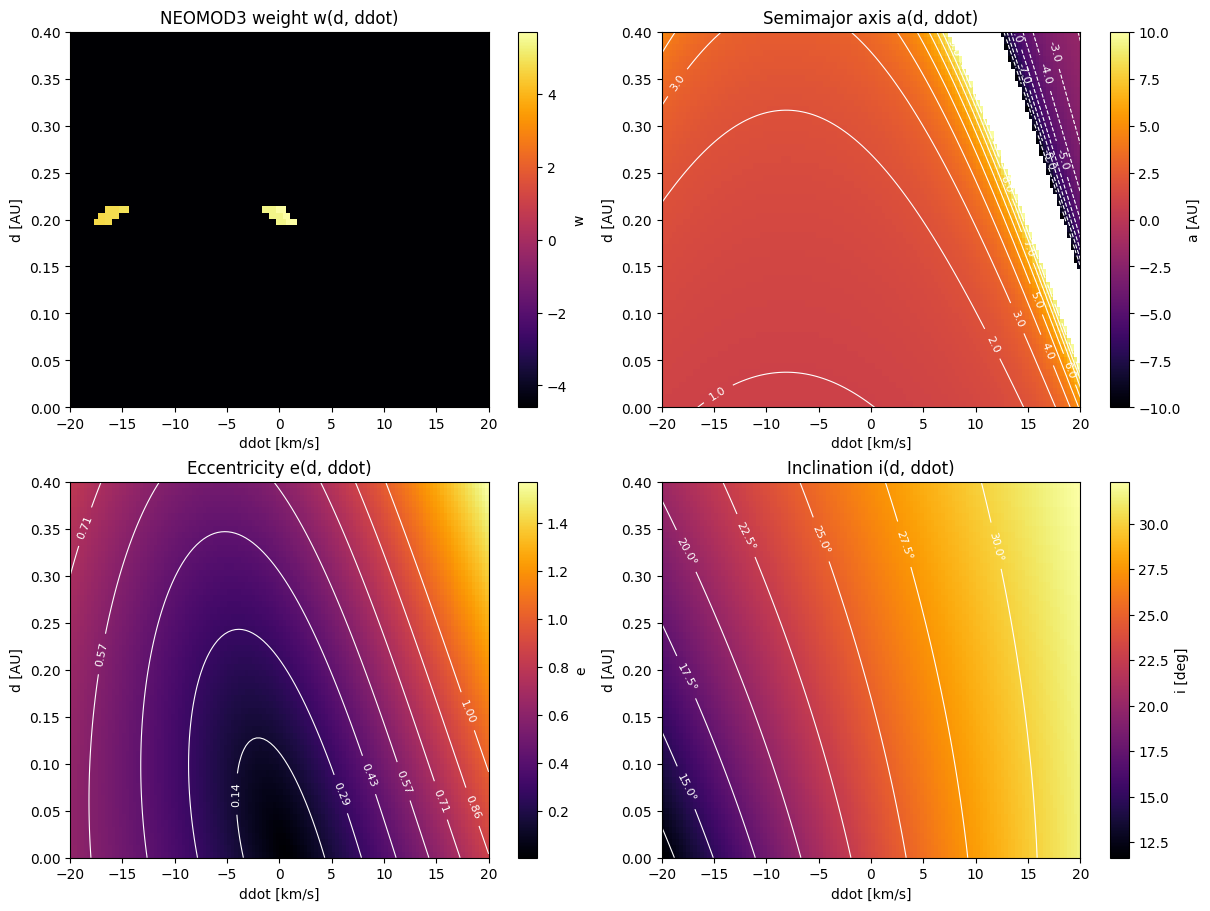

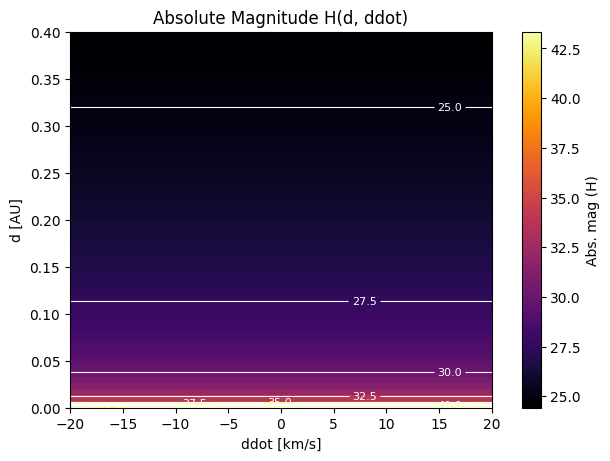

In [72]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 0.40, 60)   
v_vals = np.linspace(-20.0, 20.0, 120)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)   
H = np.zeros_like(W) 


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc, H_0= compute_neomod3_weight(d, v, l_hat, v_hat, mag, obstime,
                           rE, vE, r_obs,
                           array4D, H_center, a_center, e_center, i_center) 
        H_0 = np.asarray(H_0).squeeze()
        
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc
        H[i,j] = np.asarray(H_0).item()


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(np.log(W + 0.01), origin="lower", extent=extent, aspect="auto", cmap="inferno")
#cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")

fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

#absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()

#### So by only taking rows 